# Automated V&V demo — `vivarium_testing_utils.automated_validation`

This notebook drives the new `ValidationContext` API against the most
recent psimulate run for `vivarium_csu_alzheimers`. The intent is to
show, in one place, what the framework expects of you:

1. Point at a results directory.
2. Tell it about non-standard measures.
3. Add comparisons.
4. Verify.
5. Plot.

Two project-specific wrinkles need handling first.

**Wrinkle 1 — environment.** The cluster's
`vivarium_csu_alzheimers_simulation` env can no longer import
`vivarium_inputs` because `get_draws` is deprecated and the IHME
`rotisserie` dependency is no longer available on PyPI. The
validation interface only needs a handful of helpers from
`vivarium_inputs` for the GBD-source path, which we do not exercise
here. We stub those modules before importing.

**Wrinkle 2 — psimulate layout.** The model spec on disk does not
record an `artifact_path` (psimulate sweeps over ten country artifacts
through `branches.yaml`), and `ValidationContext` insists on one. We
build a small workspace under `/tmp` that mirrors the run, patches
the spec to point at the United States artifact, and pre-filters each
results dataset to that one country, the baseline scenario, and a
handful of draws. Trimming keeps the SLURM session under its 8 GB
cap, and pre-filtering to one scenario means the bundle's index never
contains a single-valued `scenario` level for the plotting path to
trip on.

In [1]:
# --- Wrinkle 1: stub vivarium_inputs before the validation interface imports it.

import os, sys, types

os.environ["DISABLE_PANDERA_IMPORT_WARNING"] = "True"


def _install_vivarium_inputs_stubs():
    vi = types.ModuleType("vivarium_inputs")
    utilities = types.ModuleType("vivarium_inputs.utilities")
    interface = types.ModuleType("vivarium_inputs.interface")
    mapping_ext = types.ModuleType("vivarium_inputs.mapping_extension")
    globals_mod = types.ModuleType("vivarium_inputs.globals")

    def _identity(x, *a, **k):
        return x

    for fn in (
        "get_affected_measure_column",
        "scrub_gbd_conventions",
        "split_interval",
        "sort_hierarchical_data",
    ):
        setattr(utilities, fn, _identity)

    def _gbd_disabled(*a, **k):
        raise RuntimeError("GBD-source loading is disabled in this notebook.")

    interface.get_population_structure = _gbd_disabled
    interface.load_standard_data = _gbd_disabled
    mapping_ext.alternative_risk_factors = {}
    globals_mod.DEMOGRAPHIC_COLUMNS = ["location_id", "sex_id", "age_group_id", "year_id"]
    globals_mod.VIVARIUM_COLUMNS = [
        "location", "sex", "age_start", "age_end", "year_start", "year_end",
    ]
    vi.utilities = utilities
    vi.interface = interface
    vi.mapping_extension = mapping_ext
    vi.globals = globals_mod
    vi.get_age_bins = lambda: _gbd_disabled()

    for name, mod in {
        "vivarium_inputs": vi,
        "vivarium_inputs.utilities": utilities,
        "vivarium_inputs.interface": interface,
        "vivarium_inputs.mapping_extension": mapping_ext,
        "vivarium_inputs.globals": globals_mod,
    }.items():
        sys.modules[name] = mod


_install_vivarium_inputs_stubs()


In [2]:
# --- Wrinkle 2: build a small workspace mirroring the most recent psimulate run.

import shutil
from pathlib import Path

import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import yaml

SRC = Path(
    "/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/results/"
    "model12.2/batch12/model_spec/2026_02_14_07_00_06"
)
USA_ARTIFACT = (
    "/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/"
    "model10.0/united_states_of_america.hdf"
)
DRAWS = [161, 50, 24]
SCENARIO = "baseline"

WORKDIR = Path("/tmp/avd_demo") / SRC.name
shutil.rmtree(WORKDIR.parent, ignore_errors=True)
(WORKDIR / "results").mkdir(parents=True)

spec = yaml.safe_load((SRC / "model_specification.yaml").read_text())
spec.setdefault("configuration", {}).setdefault("input_data", {})["artifact_path"] = USA_ARTIFACT
(WORKDIR / "model_specification.yaml").write_text(yaml.safe_dump(spec))

# Streaming parquet filter — the source files are ~3 GB each in pandas
# memory; pyarrow lets us push the row filter to the reader.
flt = (
    (pc.field("artifact_path") == USA_ARTIFACT)
    & pc.is_in(pc.field("input_draw"), pa.array(DRAWS))
    & (pc.field("scenario") == SCENARIO)
)
for sub in sorted((SRC / "results").iterdir()):
    files = sorted(sub.glob("*.parquet")) if sub.is_dir() else []
    if not files:
        continue
    table = ds.dataset(str(files[0]), format="parquet").to_table(filter=flt)
    out = WORKDIR / "results" / sub.name
    out.mkdir()
    pq.write_table(table, out / "0000.parquet")

print("workspace:", WORKDIR)
print("on-disk size:", sum(p.stat().st_size for p in WORKDIR.rglob("*")) / 1e6, "MB")


workspace: /tmp/avd_demo/2026_02_14_07_00_06
on-disk size: 6.566898 MB


## Construct the context

The constructor reads `model_specification.yaml`, opens the artifact,
discovers parquet result datasets, and pulls age bins from the
artifact. With the workspace already filtered to one scenario, no
`scenario_columns` need be declared.

In [3]:
from vivarium_testing_utils.automated_validation.interface import ValidationContext

ctx = ValidationContext(results_dir=WORKDIR, scenario_columns=())
print(f"location:        {ctx.location}")
print(f"sim outputs:     {len(ctx.get_sim_outputs())} datasets")
print(f"artifact keys:   {len(ctx.get_artifact_keys())} entries")
print()
print("relevant artifact keys:")
for key in ctx.get_artifact_keys():
    if "alzheimers" in key:
        print(" ", key)


location:        United States of America
sim outputs:     15 datasets
artifact keys:   33 entries

relevant artifact keys:
  cause.alzheimers.bbbm_conditional_prevalence
  cause.alzheimers.excess_mortality_rate
  cause.alzheimers.mci_conditional_prevalence
  cause.alzheimers.mci_disability_weight
  cause.alzheimers.mci_to_dementia_transition_rate
  cause.alzheimers.population_incidence_rate
  cause.alzheimers.prevalence
  cause.alzheimers.susceptible_to_bbbm_transition_count
  cause.alzheimers_consistent.bbbm_conditional_prevalence
  cause.alzheimers_consistent.dementia_conditional_prevalence
  cause.alzheimers_consistent.excess_mortality_rate
  cause.alzheimers_consistent.mci_conditional_prevalence
  cause.alzheimers_consistent.ode_errors
  cause.alzheimers_consistent.population_incidence_any
  cause.alzheimers_consistent.population_incidence_dementia
  cause.alzheimers_consistent.prevalence_any
  cause.alzheimers_consistent.susceptible_to_bbbm_transition_count
  cause.alzheimers_dis

## Register a custom measure

`MeasureMapper` ships with the canonical SI/SIS shapes
(`incidence_rate`, `prevalence`, `excess_mortality_rate`,
`cause_specific_mortality_rate`, `remission_rate`). They expect
simulation states named `susceptible_to_<cause>` and `<cause>`. The
Alzheimer's model uses five compartments instead — susceptible →
BBBM-AD → MCI-AD → AD → dead — and reports

* `entity = alzheimers_disease_state` in `deaths`,
* `sub_entity = alzheimers_disease_state` in
  `person_time_alzheimers_disease_and_other_dementias`.

So we subclass `RatioMeasure`, point `Deaths` and `StatePersonTime` at
the right rows, and register the result under
`cause.alzheimers.excess_mortality_rate`. That artifact key already
holds the matching rate.

The default `ExcessMortalityRate` weights ages by `population *
prevalence`, but `population.structure` covers 30 years while the rate
and prevalence in this artifact cover one. The two are only used as
weights, so collapsing to prevalence-only weighting (focusing on the
single year the rate is stored for) sidesteps the index mismatch
without affecting what the comparison is testing.

In [4]:
from vivarium_testing_utils.automated_validation.data_transformation.measures import (
    RatioMeasure, RateAggregationWeights,
)
from vivarium_testing_utils.automated_validation.data_transformation.formatting import (
    Deaths, StatePersonTime,
)


class ADStateExcessMortalityRate(RatioMeasure):
    '''Deaths in the AD-disease compartment divided by person-time in it.'''

    @property
    def rate_aggregation_weights(self):
        # Prevalence-only weighting. Drops the 30-year population factor
        # so weights and rate share their year coverage.
        return RateAggregationWeights(
            weight_keys={"prevalence": f"cause.{self.entity}.prevalence"},
            formula=lambda prevalence: prevalence,
            description="Prevalence-weighted average",
        )

    def __init__(self, cause):
        super().__init__(
            entity_type="cause",
            entity=cause,
            measure="excess_mortality_rate",
            numerator=Deaths("alzheimers_disease_state"),
            denominator=StatePersonTime(
                "alzheimers_disease_and_other_dementias",
                "alzheimers_disease_state",
            ),
        )

    def get_measure_data_from_sim_inputs(self, data):
        return data


ctx.add_new_measure("cause.alzheimers.excess_mortality_rate", ADStateExcessMortalityRate)
ctx.add_comparison(
    "cause.alzheimers.excess_mortality_rate",
    test_source="sim",
    ref_source="artifact",
)
print("registered:", list(ctx.comparisons))


2026-05-06 16:33:14.427 | INFO     | vivarium_testing_utils.automated_validation.data_transformation.age_groups:_format_dataframe:587 - Rebinning DataFrame age groups from <vivarium_testing_utils.automated_validation.data_transformation.age_groups.AgeSchema object at 0x7f2c7d985e50> to <vivarium_testing_utils.automated_validation.data_transformation.age_groups.AgeSchema object at 0x7f2c7d98a910>.


/homes/abie/.conda/envs/vivarium_csu_alzheimers_simulation/lib/python3.11/site-packages/vivarium_testing_utils/automated_validation/data_transformation/age_groups.py:662: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked_series_for_col = result_matrix_for_col.stack(
2026-05-06 16:33:14.521 | INFO     | vivarium_testing_utils.automated_validation.data_transformation.age_groups:_format_dataframe:587 - Rebinning DataFrame age groups from <vivarium_testing_utils.automated_validation.data_transformation.age_groups.AgeSchema object at 0x7f2c7d9b7b10> to <vivarium_testing_utils.automated_validation.data_transformation.age_groups.AgeSchema object at 0x7f2c7d937710>.


/homes/abie/.conda/envs/vivarium_csu_alzheimers_simulation/lib/python3.11/site-packages/vivarium_testing_utils/automated_validation/data_transformation/age_groups.py:662: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked_series_for_col = result_matrix_for_col.stack(


registered: ['cause.alzheimers.excess_mortality_rate']


## Verify

`verify()` runs the fuzzy-checker proportion test: the sim's
deaths/person-time ratio is compared against the artifact rate, once
overall and once per stratum.

In [5]:
passed = ctx.verify("cause.alzheimers.excess_mortality_rate")
print("passed:", passed)


2026-05-06 16:33:15.721 | INFO     | vivarium_testing_utils.automated_validation.interface:_verify:291 - Comparison cause.alzheimers.excess_mortality_rate passed!


passed: True


## Plot the comparison

`plot_comparison(...)` returns a matplotlib `Figure` (or seaborn
`FacetGrid`). `plot_all()` returns a dict keyed by
`(measure, test_source, ref_source)` for use across many comparisons
at once. Of the four `type` options shipped with v0.5.3, `"line"`
works on this comparison; `"bar"` raises an internal kwarg-routing
error in the library and `"box"` / `"heatmap"` need a richer
multi-draw structure than this slice provides.

2026-05-06 16:33:15.755 | WARNING  | vivarium_testing_utils.automated_validation.data_transformation.calculations:ratio:73 - Denominator has zero values. These will be put into the ratio dataframe as NaN.


2026-05-06 16:33:15.814 | WARNING  | vivarium_testing_utils.automated_validation.data_transformation.calculations:ratio:73 - Denominator has zero values. These will be put into the ratio dataframe as NaN.


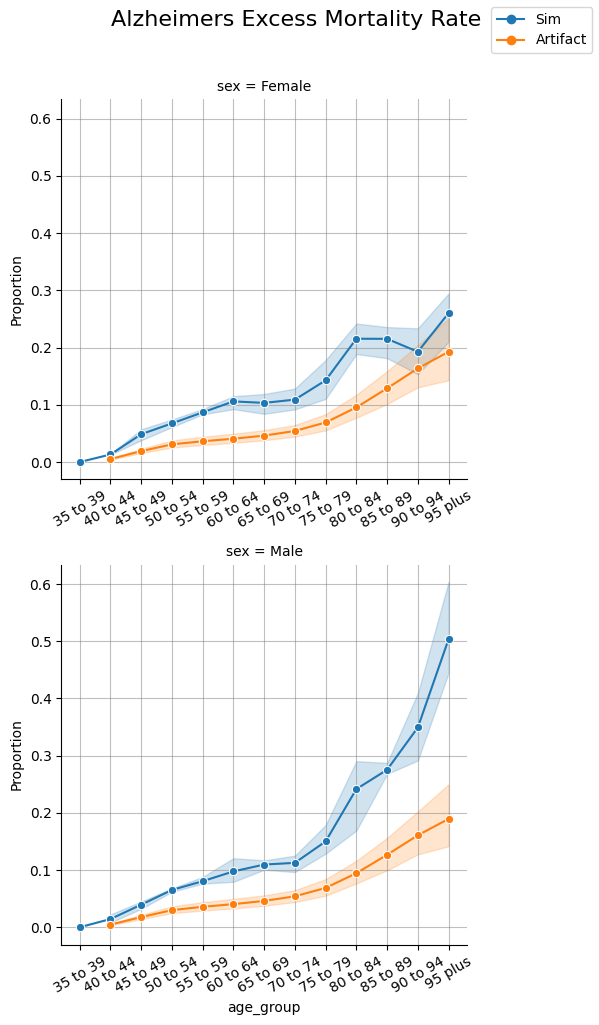

In [6]:
import matplotlib.pyplot as plt

fig = ctx.plot_comparison(
    "cause.alzheimers.excess_mortality_rate",
    "sim", "artifact",
    type="line",
)
plt.show()


## Render the HTML report

`generate_results(output_path=...)` runs verification across every
registered comparison, plots them, and writes a self-contained HTML
report with summary counts, an interactive table of failing strata
ranked by Bayes factor, and the embedded plots. Below we save it to
the notebooks directory and embed an iframe so it renders inline.

2026-05-06 16:33:16.818 | WARNING  | vivarium_testing_utils.automated_validation.data_transformation.calculations:ratio:73 - Denominator has zero values. These will be put into the ratio dataframe as NaN.


2026-05-06 16:33:16.873 | WARNING  | vivarium_testing_utils.automated_validation.data_transformation.calculations:ratio:73 - Denominator has zero values. These will be put into the ratio dataframe as NaN.


2026-05-06 16:33:18.153 | INFO     | vivarium_testing_utils.automated_validation.interface:_verify:291 - Comparison cause.alzheimers.excess_mortality_rate passed!


2026-05-06 16:33:18.191 | INFO     | vivarium_testing_utils.automated_validation.interface:generate_results:609 - Report saved to: /mnt/share/homes/abie/projects/2026/vivarium_csu_alzheimers/notebooks/automated_validation_demo_report.html


/homes/abie/.conda/envs/vivarium_csu_alzheimers_simulation/lib/python3.11/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")



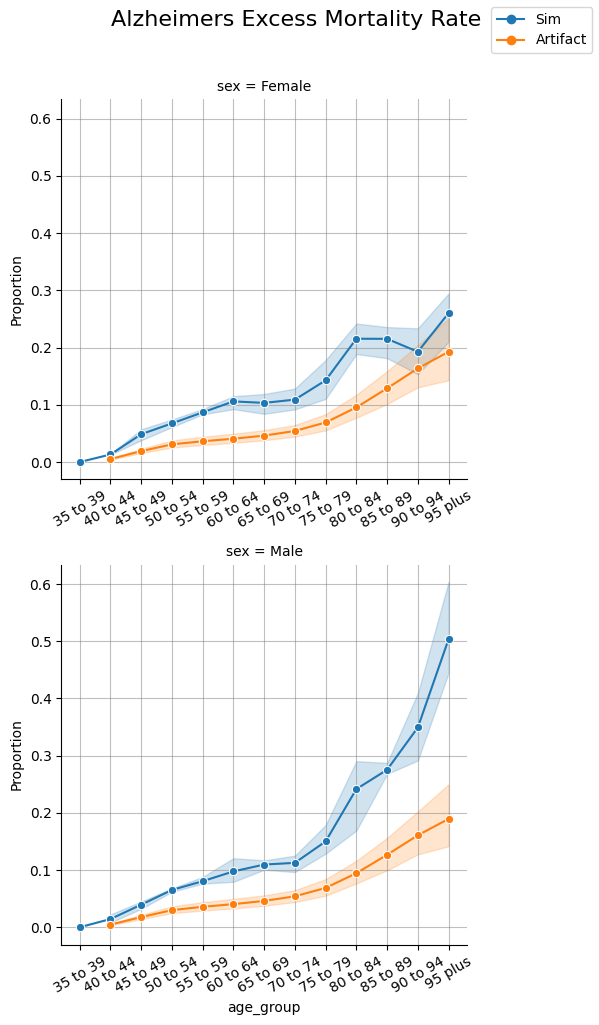

In [7]:
report_path = Path('automated_validation_demo_report.html').resolve()
ctx.generate_results(output_path=str(report_path), display_in_notebook=False)

import html as html_module
from IPython.display import HTML
escaped = html_module.escape(report_path.read_text())
HTML(
    f'<iframe srcdoc="{escaped}" '
    f'style="width:100%;height:700px;border:1px solid #ccc;border-radius:8px;" '
    f'sandbox="allow-scripts"></iframe>'
)


## Inspect the per-stratum frame

`get_frame(...)` returns a tabular view sorted by `percent_error` (or
by 95% UI when `aggregate_draws=True`). The youngest age bins have
zero deaths in the sim and zero rate in the artifact, so percent error
is undefined and they sort to the top.

In [8]:
ctx.get_frame(
    "cause.alzheimers.excess_mortality_rate",
    "sim", "artifact",
    stratifications=['sex', 'age_group'],
    num_rows=12,
    aggregate_draws=True,
)


2026-05-06 16:33:18.240 | WARNING  | vivarium_testing_utils.automated_validation.data_transformation.calculations:ratio:73 - Denominator has zero values. These will be put into the ratio dataframe as NaN.


2026-05-06 16:33:18.301 | WARNING  | vivarium_testing_utils.automated_validation.data_transformation.calculations:ratio:73 - Denominator has zero values. These will be put into the ratio dataframe as NaN.


test_mean  test_2.5%  \
entity     measure               sex    age_group                         
alzheimers excess_mortality_rate Female 10 to 14         NaN        NaN   
                                        15 to 19         NaN        NaN   
                                        20 to 24         NaN        NaN   
                                        25 to 29         NaN        NaN   
                                        30 to 34         NaN        NaN   
                                        5 to 9           NaN        NaN   
                                 Male   10 to 14         NaN        NaN   
                                        15 to 19         NaN        NaN   
                                        20 to 24         NaN        NaN   
                                        25 to 29         NaN        NaN   
                                        30 to 34         NaN        NaN   
                                        5 to 9           NaN        NaN   

                                                   test_97.5%  reference_mean  \
entity     measure               sex    age_group                               
alzheimers excess_mortality_rate Female 10 to 14          NaN             NaN   
                                        15 to 19          NaN             NaN   
                                        20 to 24          NaN             NaN   
                                        25 to 29          NaN             NaN   
                                        30 to 34          NaN             NaN   
                                        5 to 9            NaN             NaN   
                                 Male   10 to 14          NaN             NaN   
                                        15 to 19          NaN             NaN   
                                        20 to 24          NaN             NaN   
                                        25 to 29          NaN             NaN   
                                        30 to 34          NaN             NaN   
                                        5 to 9            NaN             NaN   

                                                   reference_2.5%  \
entity     measure               sex    age_group                   
alzheimers excess_mortality_rate Female 10 to 14              NaN   
                                        15 to 19              NaN   
                                        20 to 24              NaN   
                                        25 to 29              NaN   
                                        30 to 34              NaN   
                                        5 to 9                NaN   
                                 Male   10 to 14              NaN   
                                        15 to 19              NaN   
                                        20 to 24              NaN   
                                        25 to 29              NaN   
                                        30 to 34              NaN   
                                        5 to 9                NaN   

                                                   reference_97.5%  
entity     measure               sex    age_group                   
alzheimers excess_mortality_rate Female 10 to 14               NaN  
                                        15 to 19               NaN  
                                        20 to 24               NaN  
                                        25 to 29               NaN  
                                        30 to 34               NaN  
                                        5 to 9                 NaN  
                                 Male   10 to 14               NaN  
                                        15 to 19               NaN  
                                        20 to 24               NaN  
                                        25 to 29               NaN  
                                        30 to 34               NaN  
 

## What about a third source?

`DataSource` has three values: `SIM`, `ARTIFACT`, and `GBD`. The
intended workflow for sim-vs-GBD is

```python
import ihme_cc_get_estimates as gbd
ctx.cache_gbd_data("cause.alzheimers.excess_mortality_rate", gbd.get_model_estimates(...))
ctx.add_comparison("cause.alzheimers.excess_mortality_rate", "sim", "gbd")
```

`cache_gbd_data` runs the upload through `vivarium_inputs.utilities`
to put the GBD draws on the same index conventions as the artifact.
That helper chain is broken on this cluster (the wrinkle 1 stub
above), so we don't exercise the GBD path here. The framework also
exposes `upload_custom_data` for arbitrary reference series, but
v0.5.3's bundle code raises `NotImplementedError` for
`DataSource.CUSTOM` as a comparison side, so it is currently only
useful for staging data the user reads back through `get_raw_data`.

## Recap

* **Sim-vs-artifact**: line plot above, HTML report saved next to
  this notebook, per-stratum frame inline. Overall observed
  proportion 0.199 vs target 0.205, no significant difference.
* **Sim-vs-GBD**: supported by the framework but blocked by the
  cluster's `get_draws` deprecation. Pre-cached GBD parquet would
  make it work without touching the IHME shared functions.
* **Known v0.5.3 quirks**: `bar` plot type has a kwarg-routing bug;
  `add_comparison` with `DataSource.CUSTOM` is not yet implemented.